# 02 — Adoption, Engagement, and Feedback Analysis

**GenAI Enterprise Adoption Intelligence Hub** (Northstar Financial Group / Northstar Assist — fictional)

> **Synthetic portfolio data.** Northstar Financial Group and Northstar Assist are fictional. All figures below are generated by `src/generate_synthetic_data.py` with a fixed random seed and must never be read as real enterprise data, real user behavior, or validated ROI. See `docs/assumptions_and_limitations.md` for the full integrity statement.

This notebook applies every metric function in `src/analysis.py` to the cleaned dataset and charts the results. Metric definitions (numerator, denominator, timeframe, caveats) are documented in `docs/metric_dictionary.md` — read this notebook alongside it, not instead of it.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))
from src import analysis as ga

NAVY, BLUE, LIGHT_BLUE, GRAY = '#1b3a6b', '#2f5f9e', '#5b8fc7', '#888888'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.facecolor'] = 'white'

PROCESSED_DIR = os.path.join('..', 'data', 'processed')
data = ga.load_data(PROCESSED_DIR)
users, events, feedback, calendar = data['users'], data['events'], data['feedback'], data['calendar']
print('Loaded processed synthetic data:', {k: len(v) for k, v in data.items()})

Loaded processed synthetic data: {'users': 6000, 'events': 236960, 'feedback': 7677, 'training': 61, 'features': 8, 'calendar': 168}


## 1. Eligibility and activation

**Activated user** = eligible user who (completed training OR used Prompt Library) AND completed >= 3 meaningful actions within 14 days of `assigned_access_date`. This is a designed, association-based definition — see `docs/metric_dictionary.md` for the full caveat.

In [2]:
overall = ga.activation_rate(users, events)
print('Overall (synthetic):')
print(overall)

by_bu = ga.activation_rate(users, events, groupby='business_unit').sort_values('activation_rate_pct')
by_bu

Overall (synthetic):
eligible_users         5693.0
activated_users        4475.0
activation_rate_pct      78.6
dtype: float64


,business_unit,eligible_users,activated_users,activation_rate_pct
4,Retail Banking,1652,1187,71.9
3,Operations,1019,734,72.0
2,Corporate Functions,317,246,77.6
5,Risk and Compliance,435,341,78.4
1,Commercial Banking,686,561,81.8
7,Wealth Management,458,379,82.8
0,Capital Markets,444,385,86.7
6,Technology,682,642,94.1


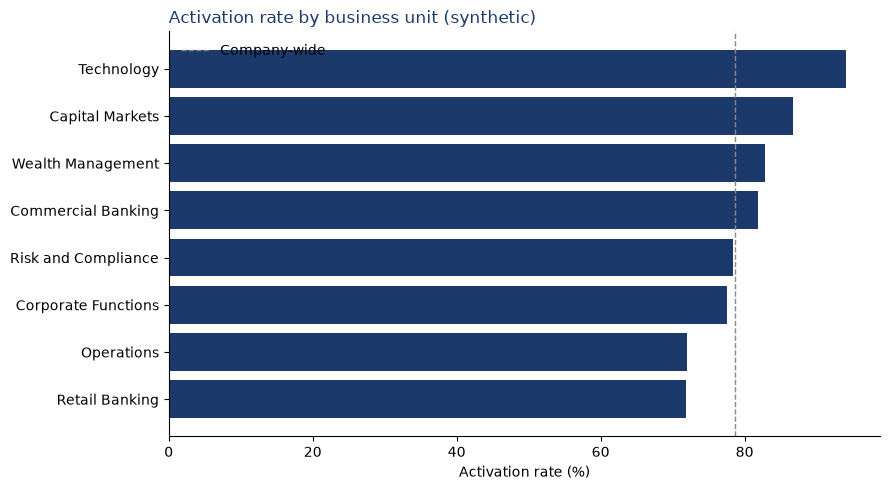

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(by_bu['business_unit'], by_bu['activation_rate_pct'], color=NAVY)
ax.axvline(overall['activation_rate_pct'], color=GRAY, linestyle='--', linewidth=1, label='Company-wide')
ax.set_xlabel('Activation rate (%)')
ax.set_title('Activation rate by business unit (synthetic)', fontsize=12, color=NAVY, loc='left')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 2. Weekly Active Users (WAU) over the 24-week rollout

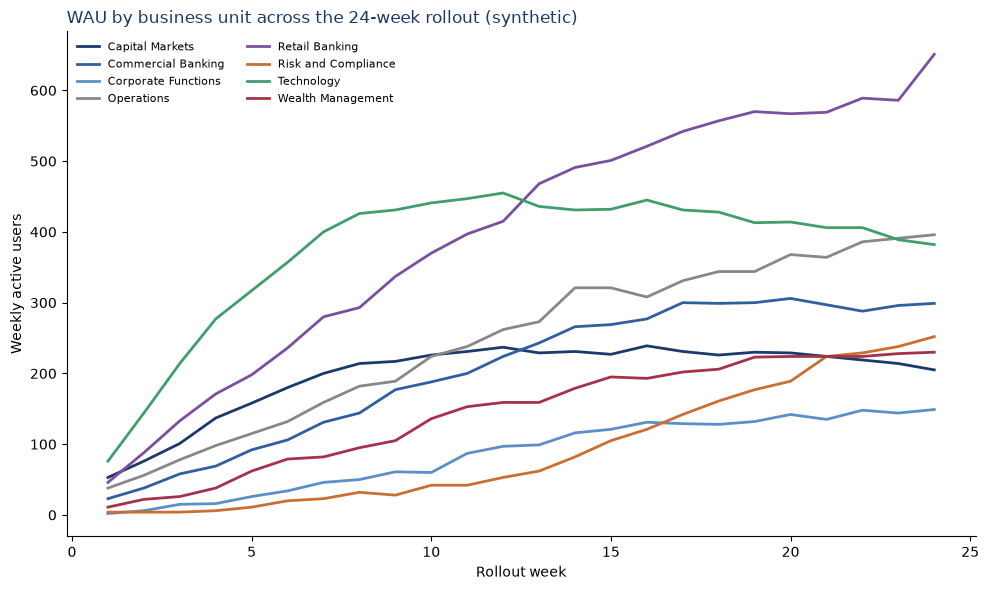

In [4]:
wau_bu = ga.weekly_active_users(events, calendar, users=users, groupby='business_unit')
pivot = wau_bu.pivot(index='week_number', columns='business_unit', values='weekly_active_users')

fig, ax = plt.subplots(figsize=(10, 6))
colors = [NAVY, BLUE, LIGHT_BLUE, GRAY, '#7a4fa0', '#c96f34', '#3f9e6c', '#a3324a']
for i, col in enumerate(pivot.columns):
    ax.plot(pivot.index, pivot[col], label=col, color=colors[i % len(colors)], linewidth=2)
ax.set_xlabel('Rollout week')
ax.set_ylabel('Weekly active users')
ax.set_title('WAU by business unit across the 24-week rollout (synthetic)', fontsize=12, color=NAVY, loc='left')
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

**Interpretation:** Technology and Capital Markets ramp fastest; Risk and Compliance starts near zero and climbs steadily — consistent with the scenario's designed rollout-wave and caution-then-adoption pattern. This is a designed pattern in the synthetic generator, not an observed real-world effect.

## 3. MAU (28-day) and stickiness

Company-wide MAU (trailing 28 days as of the last event in the dataset): 3,502


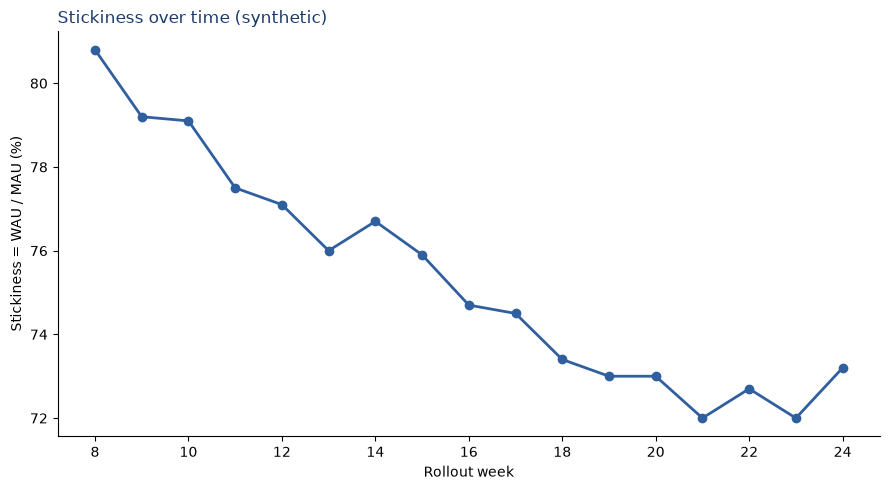

In [5]:
mau = ga.mau_28d(events)
print(f'Company-wide MAU (trailing 28 days as of the last event in the dataset): {mau:,}')

sticky_weeks = list(range(8, 25))
sticky_values = [ga.stickiness(events, calendar, week_number=w) for w in sticky_weeks]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sticky_weeks, sticky_values, color=BLUE, marker='o', linewidth=2)
ax.set_xlabel('Rollout week')
ax.set_ylabel('Stickiness = WAU / MAU (%)')
ax.set_title('Stickiness over time (synthetic)', fontsize=12, color=NAVY, loc='left')
plt.tight_layout()
plt.show()

**Caveat:** stickiness is a proxy for engagement *depth*, not a complete measure of value delivered.

## 4. Feature adoption

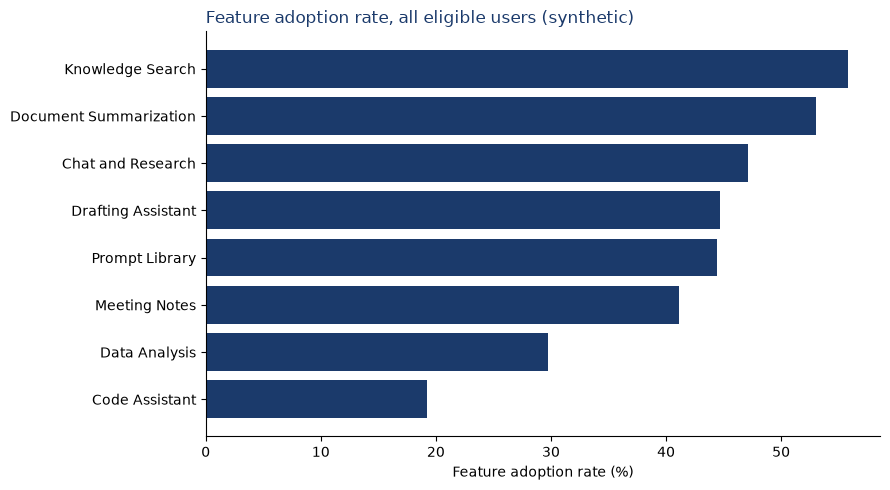

In [6]:
feat = ga.feature_adoption_rate(users, events).sort_values('feature_adoption_rate_pct')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feat['feature_name'], feat['feature_adoption_rate_pct'], color=NAVY)
ax.set_xlabel('Feature adoption rate (%)')
ax.set_title('Feature adoption rate, all eligible users (synthetic)', fontsize=12, color=NAVY, loc='left')
plt.tight_layout()
plt.show()

## 5. Time-to-value

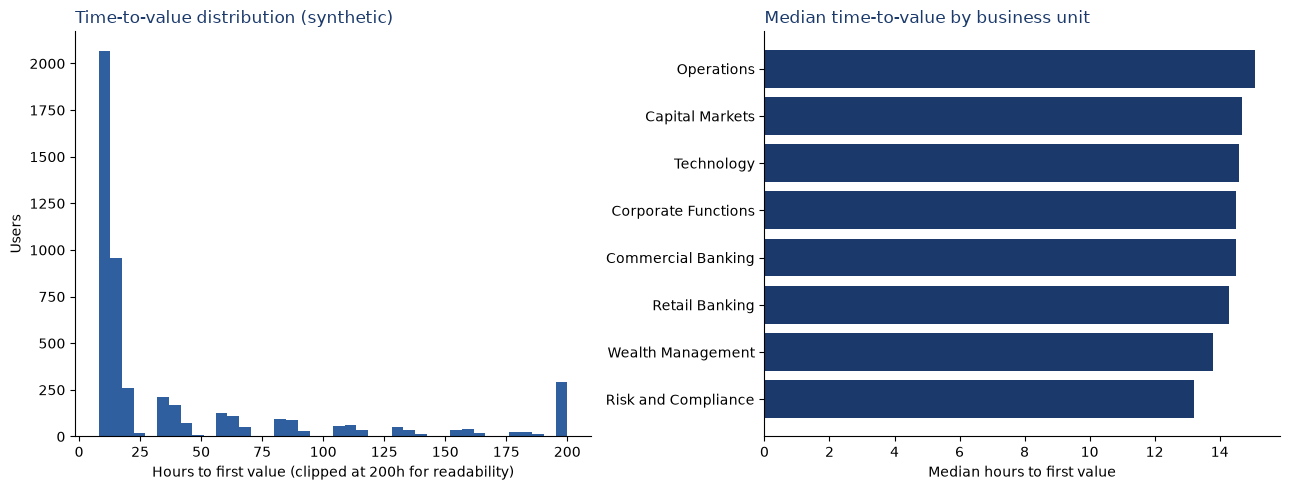

In [7]:
ttv = ga.time_to_value(users, events)
median_ttv = ga.median_time_to_value(users, events)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(ttv['hours_to_value'].clip(upper=200), bins=40, color=BLUE)
axes[0].set_xlabel('Hours to first value (clipped at 200h for readability)')
axes[0].set_ylabel('Users')
axes[0].set_title('Time-to-value distribution (synthetic)', fontsize=12, color=NAVY, loc='left')

median_ttv_sorted = median_ttv.sort_values('median_hours_to_value')
axes[1].barh(median_ttv_sorted['business_unit'], median_ttv_sorted['median_hours_to_value'], color=NAVY)
axes[1].set_xlabel('Median hours to first value')
axes[1].set_title('Median time-to-value by business unit', fontsize=12, color=NAVY, loc='left')

plt.tight_layout()
plt.show()

## 6. Retention cohorts

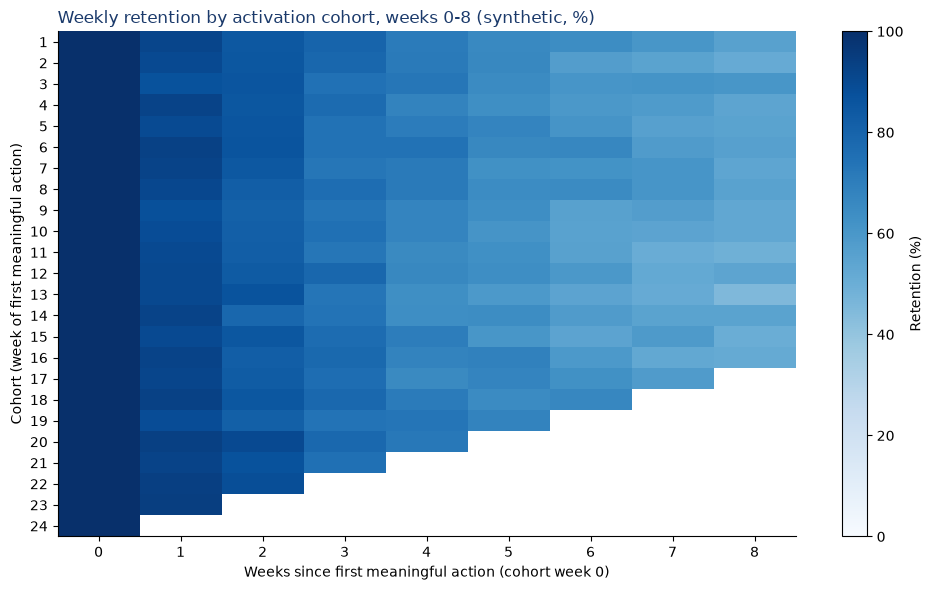

In [8]:
cohorts = ga.retention_cohorts(events, calendar)
cohort_pivot = cohorts.pivot(index='cohort_week', columns='weeks_since_activation', values='retention_rate_pct')

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(cohort_pivot.values, cmap='Blues', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(cohort_pivot.columns)))
ax.set_xticklabels(cohort_pivot.columns)
ax.set_yticks(range(len(cohort_pivot.index)))
ax.set_yticklabels(cohort_pivot.index)
ax.set_xlabel('Weeks since first meaningful action (cohort week 0)')
ax.set_ylabel('Cohort (week of first meaningful action)')
ax.set_title('Weekly retention by activation cohort, weeks 0-8 (synthetic, %)', fontsize=12, color=NAVY, loc='left')
fig.colorbar(im, ax=ax, label='Retention (%)')
plt.tight_layout()
plt.show()

## 7. Training completion vs. activation (association, not causation)

             training_status  eligible_users  activated_users  \
0         Completed Training            3778             3213   
1  Did Not Complete Training            1915             1262   

   activation_rate_pct  
0                 85.0  
1                 65.9  


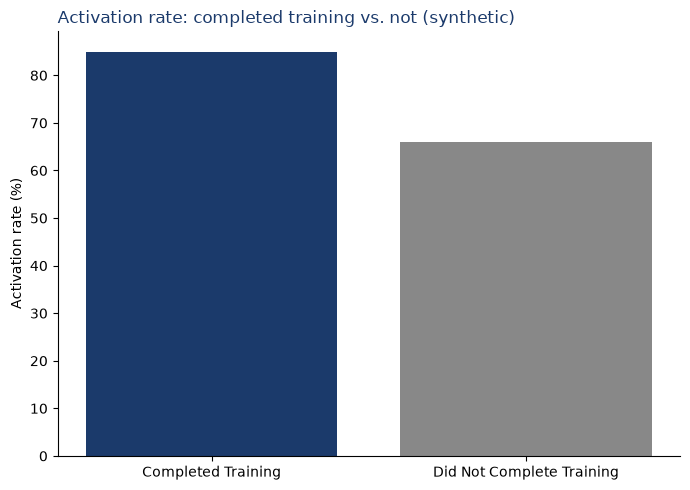

In [9]:
tva = ga.training_vs_activation(users, events)
print(tva)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(tva['training_status'], tva['activation_rate_pct'], color=[NAVY, GRAY])
ax.set_ylabel('Activation rate (%)')
ax.set_title('Activation rate: completed training vs. not (synthetic)', fontsize=12, color=NAVY, loc='left')
plt.tight_layout()
plt.show()

**Caveat (important):** training completion is not randomly assigned in this dataset — users who complete training may differ from those who don't in other ways the data doesn't capture (motivation, workload, manager support). This chart shows an **association**, and the synthetic generator was explicitly designed to produce one; it is not evidence that training *causes* activation.

## 8. Dormancy

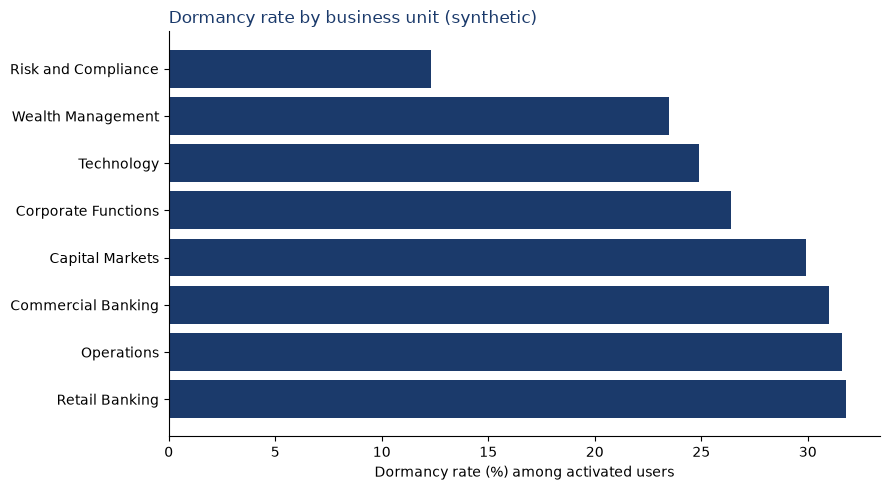

In [10]:
dormant = ga.dormant_users(users, events)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(dormant['business_unit'], dormant['dormancy_rate_pct'], color=NAVY)
ax.set_xlabel('Dormancy rate (%) among activated users')
ax.set_title('Dormancy rate by business unit (synthetic)', fontsize=12, color=NAVY, loc='left')
plt.tight_layout()
plt.show()

## 9. Modeled estimated time saved (NOT validated ROI)

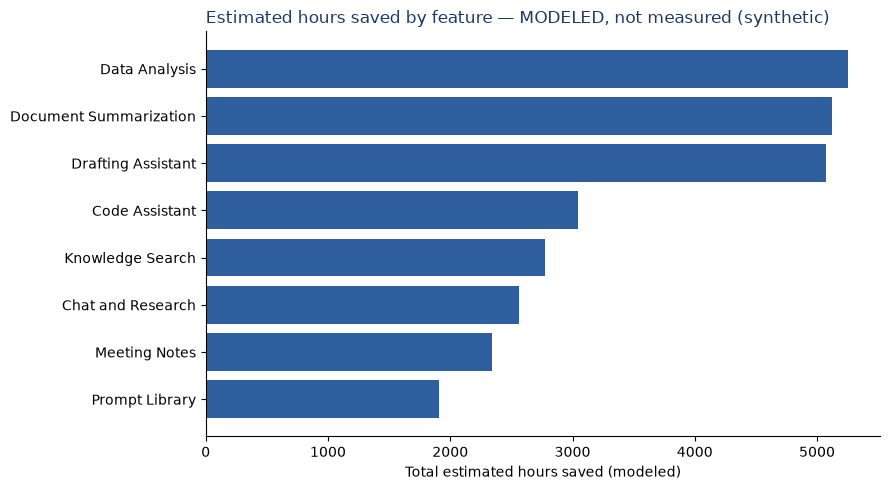

estimated_minutes_saved / estimated_hours_saved are MODELED ASSUMPTIONS built into the synthetic data generator, not measured or validated ROI.


In [11]:
time_saved = ga.estimated_time_saved(events).sort_values('total_estimated_hours_saved')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(time_saved['feature_name'], time_saved['total_estimated_hours_saved'], color=BLUE)
ax.set_xlabel('Total estimated hours saved (modeled)')
ax.set_title('Estimated hours saved by feature — MODELED, not measured (synthetic)', fontsize=12, color=NAVY, loc='left')
plt.tight_layout()
plt.show()

print(ga.TIME_SAVED_DISCLAIMER)

## 10. Feedback: recommendation rate and top barriers by business unit

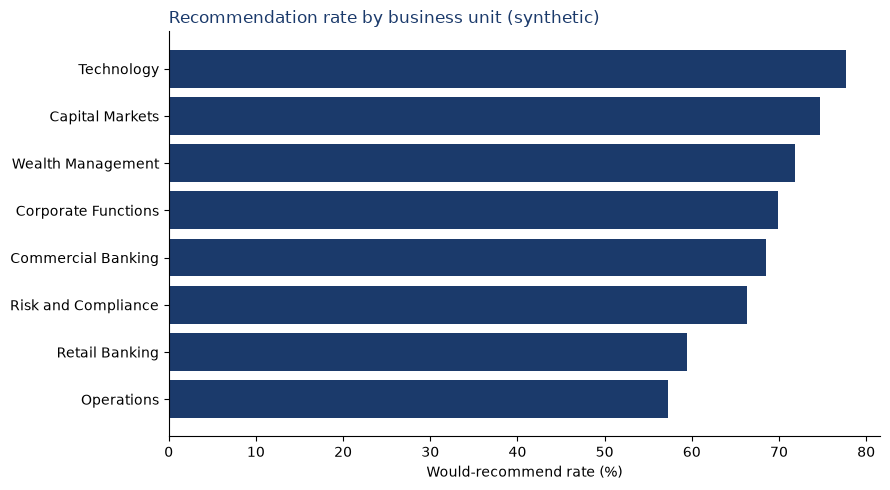

In [12]:
rec_by_bu = ga.recommendation_rate(feedback.merge(users[['user_id', 'business_unit']], on='user_id'), groupby='business_unit')
rec_by_bu = rec_by_bu.sort_values('recommendation_rate_pct')

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(rec_by_bu['business_unit'], rec_by_bu['recommendation_rate_pct'], color=NAVY)
ax.set_xlabel('Would-recommend rate (%)')
ax.set_title('Recommendation rate by business unit (synthetic)', fontsize=12, color=NAVY, loc='left')
plt.tight_layout()
plt.show()

In [13]:
barriers = ga.barrier_ranking(feedback, users)
top_barrier_per_bu = barriers[barriers['barrier_rank'] == 1][['business_unit', 'barrier_category', 'mentions']]
top_barrier_per_bu.sort_values('business_unit')

,business_unit,barrier_category,mentions
3,Capital Markets,No time to learn,50
10,Commercial Banking,No time to learn,80
17,Corporate Functions,No time to learn,53
24,Operations,No time to learn,308
31,Retail Banking,No time to learn,428
41,Risk and Compliance,Unsure what use cases are allowed,99
45,Technology,No time to learn,61
52,Wealth Management,No time to learn,66


## 11. Summary of findings (synthetic data — not causal, not real-world evidence)

- Activation rate varies meaningfully by business unit, with Technology highest and Retail Banking / Operations lowest — consistent with the designed scenario of high headcount but uneven training attendance in those units.
- Risk and Compliance shows the **fastest** median time-to-value and the **lowest** dormancy rate once activated, despite starting slow on WAU — an interesting designed pattern worth flagging in the executive memo, with the explicit caveat that it reflects the generator's built-in assumption that this unit's engagement improves sharply after training and approved-use-case communications.
- Users who completed training show a meaningfully higher activation rate than those who didn't — reported here strictly as an **association**, per the caveat above.
- Knowledge Search and Document Summarization have the broadest adoption; Code Assistant and Data Analysis are concentrated among technical roles, matching the intended feature-usage design.
- "No time to learn" and "Lack of relevant training" dominate barriers in high-headcount, operational business units; "Unsure what use cases are allowed" and "Privacy or compliance concern" dominate in Risk and Compliance.

**All of the above describes a synthetic, fictional dataset generated for portfolio purposes. No figure in this notebook — including any 'time saved' number — should be cited as real productivity impact, validated ROI, or evidence about real GenAI adoption.**